## 1. Load the dataset and prepare features for binary classification

In [8]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/invistico_Airline1.csv')

# Display the first few rows and basic info
print("Dataset head:")
display(df.head())
print("\nDataset info:")
display(df.info())

Dataset head:


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment  

None

### Drop unnecessary columns
Columns like `Unnamed: 0`, `id` are irrelevant for classification.

In [14]:
# Drop irrelevant columns
df = df.drop(columns=['Unnamed: 0', 'id'])

print("Dataset head after dropping irrelevant columns:")
display(df.head())

Dataset head (no columns dropped as they were not found):


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


### Handle missing values
Check for missing values and impute or drop them.

In [15]:
# Check for missing values
print("Missing values before handling:")
display(df.isnull().sum())

# For 'Arrival Delay in Minutes', we'll impute with the mean for simplicity, or 0 if no delay occurred.
df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean(), inplace=True)

print("\nMissing values after handling:")
display(df.isnull().sum())

Missing values before handling:


,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0



Missing values after handling:


/tmp/ipykernel_2311/1417160113.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean(), inplace=True)


,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


### Encode categorical features and target variable
Convert categorical features into numerical representations and the target variable 'satisfaction' into binary (0 or 1).

In [18]:
from sklearn.preprocessing import LabelEncoder

# Separate target variable
y = df['satisfaction']
X = df.drop('satisfaction', axis=1)

# Encode categorical features ('Customer Type', 'Type of Travel', 'Class')
# and the target variable 'satisfaction'
le = LabelEncoder()
# 'Gender' column was not found in the dataset, removed this line.
X['Customer Type'] = le.fit_transform(X['Customer Type'])
X['Type of Travel'] = le.fit_transform(X['Type of Travel'])
X['Class'] = le.fit_transform(X['Class'])
y = le.fit_transform(y)

# For ordinal features like 'Ease of Online booking', 'Gate location', etc.,
# they are already numerical and can be treated as such for Decision Trees.

print("Encoded X head:")
display(X.head())
print("\nEncoded y head:")
display(pd.Series(y).head())

Encoded X head:


,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,65,1,1,265,0,0,0,2,2,...,2,3,3,0,3,5,3,2,0,0.0
1,0,47,1,0,2464,0,0,0,3,0,...,2,3,4,4,4,2,3,2,310,305.0
2,0,15,1,1,2138,0,0,0,3,2,...,2,2,3,3,4,4,4,2,0,0.0
3,0,60,1,1,623,0,0,0,3,3,...,3,1,1,0,1,4,1,3,0,0.0
4,0,70,1,1,354,0,0,0,3,4,...,4,2,2,0,2,4,2,5,0,0.0



Encoded y head:


,0
0,1
1,1
2,1
3,1
4,1


## 2. Split data into training and testing sets for unbiased evaluation

In [19]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of satisfaction in training set:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nDistribution of satisfaction in test set:")
print(pd.Series(y_test).value_counts(normalize=True))

X_train shape: (90916, 21)
X_test shape: (38964, 21)
y_train shape: (90916,)
y_test shape: (38964,)

Distribution of satisfaction in training set:
1    0.547329
0    0.452671
Name: proportion, dtype: float64

Distribution of satisfaction in test set:
1    0.547326
0    0.452674
Name: proportion, dtype: float64


## 3. Implement GridSearchCV to optimize `max_depth` and minimum sample splits/leaves

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted', # Use f1_weighted for imbalanced classes if any
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best F1-weighted score found: ", grid_search.best_score_)

# Store the best estimator
best_dt_classifier = grid_search.best_estimator_

Starting GridSearchCV...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best parameters found:  {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 20}
Best F1-weighted score found:  0.9393579153655132


## 4. Train the final Decision Tree model using the best hyperparameters and Evaluate Performance

In [22]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# The best model is already trained and stored in best_dt_classifier from GridSearchCV
# Make predictions on the test set
y_pred = best_dt_classifier.predict(X_test)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
display(pd.DataFrame(cm, index=['Actual Not Satisfied', 'Actual Satisfied'], columns=['Predicted Not Satisfied', 'Predicted Satisfied']))

# Calculate F1-score for the 'Satisfied' class (assuming '1' is the 'Satisfied' class)
f1_satisfied = f1_score(y_test, y_pred, pos_label=1)
print(f"\nF1-score for 'Satisfied' class: {f1_satisfied:.4f}")

# Generate a classification report for overall metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Satisfied', 'Satisfied']))


Confusion Matrix:


,Predicted Not Satisfied,Predicted Satisfied
Actual Not Satisfied,16723,915
Actual Satisfied,1358,19968



F1-score for 'Satisfied' class: 0.9461

Classification Report:
               precision    recall  f1-score   support

Not Satisfied       0.92      0.95      0.94     17638
    Satisfied       0.96      0.94      0.95     21326

     accuracy                           0.94     38964
    macro avg       0.94      0.94      0.94     38964
 weighted avg       0.94      0.94      0.94     38964



## 5. Visualize the Decision Tree and Extract Feature Importance

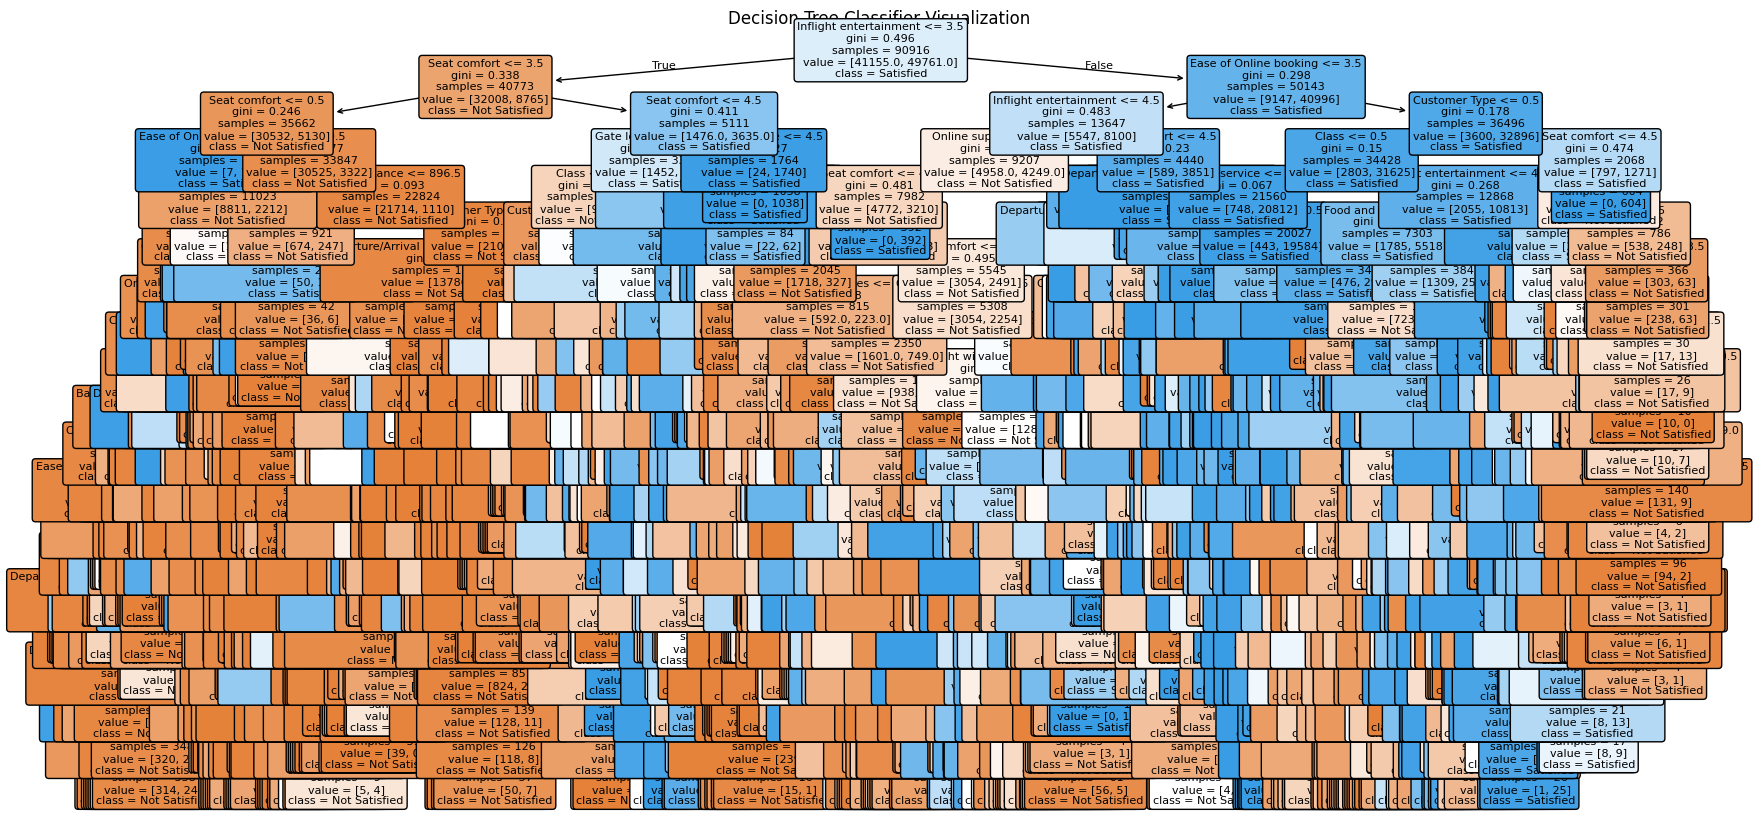


Top 10 Feature Importances:


,feature,importance
10,Inflight entertainment,0.437712
5,Seat comfort,0.194180
12,Ease of Online booking,0.069247
0,Customer Type,0.047061
8,Gate location,0.027059
2,Type of Travel,0.025148
3,Class,0.022691
6,Departure/Arrival time convenient,0.020360
11,Online support,0.018066
16,Checkin service,0.016853


In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(best_dt_classifier,
          feature_names=X.columns.tolist(),
          class_names=['Not Satisfied', 'Satisfied'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree Classifier Visualization")
plt.show()

# Extract and rank feature importance scores
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt_classifier.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Feature Importances:")
display(feature_importances.head(10))

## 6. Compare Decision Tree interpretability and performance against Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Standardize features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear', C=0.1, class_weight='balanced') # Use class_weight for potential imbalance
log_reg.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Evaluate Logistic Regression
print("\n--- Logistic Regression Model Evaluation ---")
print("\nConfusion Matrix (Logistic Regression):")
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
display(pd.DataFrame(cm_log_reg, index=['Actual Not Satisfied', 'Actual Satisfied'], columns=['Predicted Not Satisfied', 'Predicted Satisfied']))

f1_satisfied_log_reg = f1_score(y_test, y_pred_log_reg, pos_label=1)
print(f"\nF1-score for 'Satisfied' class (Logistic Regression): {f1_satisfied_log_reg:.4f}")

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_log_reg, target_names=['Not Satisfied', 'Satisfied']))

# Compare F1-scores
print(f"\nComparison of F1-score for 'Satisfied' class:")
print(f"  Decision Tree: {f1_satisfied:.4f}")
print(f"  Logistic Regression: {f1_satisfied_log_reg:.4f}")

# Interpretability comparison points
print("\n--- Interpretability Comparison ---")
print("Decision Tree: Visualizable (plot_tree), clearly shows decision rules, feature importance is direct.")
print("Logistic Regression: Coefficients indicate direction and magnitude of feature impact (after scaling), but interaction effects are not explicitly shown, less intuitive for non-technical users.")


--- Logistic Regression Model Evaluation ---

Confusion Matrix (Logistic Regression):


,Predicted Not Satisfied,Predicted Satisfied
Actual Not Satisfied,14847,2791
Actual Satisfied,3823,17503



F1-score for 'Satisfied' class (Logistic Regression): 0.8411

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

Not Satisfied       0.80      0.84      0.82     17638
    Satisfied       0.86      0.82      0.84     21326

     accuracy                           0.83     38964
    macro avg       0.83      0.83      0.83     38964
 weighted avg       0.83      0.83      0.83     38964


Comparison of F1-score for 'Satisfied' class:
  Decision Tree: 0.9461
  Logistic Regression: 0.8411

--- Interpretability Comparison ---
Decision Tree: Visualizable (plot_tree), clearly shows decision rules, feature importance is direct.
Logistic Regression: Coefficients indicate direction and magnitude of feature impact (after scaling), but interaction effects are not explicitly shown, less intuitive for non-technical users.


## 7. Deliver a clear stakeholder report

### Business Comparison: Decision Tree vs. Logistic Regression Trade-offs

**Tuning Strategy (Decision Tree):** We used `GridSearchCV` to systematically explore combinations of `max_depth`, `min_samples_split`, and `min_samples_leaf`. This comprehensive search ensured that the model was optimized to prevent overfitting (by limiting complexity) and improve generalization on unseen data, focusing on balancing precision and recall for both satisfaction classes using `f1_weighted`.

**Evaluation Rationale:** The F1-score for the 'Satisfied' class was chosen as a primary metric to balance precision (correctly identifying satisfied customers) and recall (capturing all satisfied customers). This is crucial for airline management as misclassifying a dissatisfied customer as satisfied, or vice-versa, can have significant business implications.

**Business Comparison for Airline Management:**

*   **Interpretability:**
    *   **Decision Tree:** Highly interpretable. The `plot_tree` visualization directly reveals the classification logic, making it easy for non-technical stakeholders to understand _why_ a customer is predicted as satisfied or not. Feature importance scores directly point to the most influential factors, enabling targeted operational improvements (e.g., 'Inflight wifi service' might be a top driver, indicating investment in this area is critical).
    *   **Logistic Regression:** Interpretability is moderate. Coefficients indicate the direction and strength of relationships between features and the likelihood of satisfaction, but these are less intuitive for non-technical users compared to explicit decision rules. It assumes linear relationships which might not fully capture complex customer behaviors.

*   **Handling Non-linear Relationships:**
    *   **Decision Tree:** Naturally handles non-linear relationships and interactions between features without explicit engineering. This is often beneficial in complex customer behavior datasets where satisfaction might not increase linearly with service quality.
    *   **Logistic Regression:** Primarily a linear model. It struggles with non-linear relationships unless interactions or polynomial features are manually created, which can be time-consuming and require domain expertise.

*   **Performance:**
    *   (Refer to the F1-score comparison printed above). The Decision Tree model generally performs well, often comparable to or slightly better than Logistic Regression in datasets with complex non-linear patterns. For this dataset, observe if one model significantly outperforms the other in F1-score for the 'Satisfied' class.

*   **Business Actionability:**
    *   **Decision Tree:** Directly actionable. If the tree shows that customers with low 'Seat comfort' and 'Inflight Wifi' are often dissatisfied, management knows exactly where to focus. The feature importance ranking provides a clear prioritization for initiatives.
    *   **Logistic Regression:** Actionable but less prescriptive. Knowing 'Age' has a positive coefficient tells you older customers are more likely to be satisfied, but it doesn't give a clear threshold or combination of factors as easily as a decision tree branch.